# Loan Default Prediction — Credit Risk Modeling
### Dataset: https://www.kaggle.com/datasets/nikhil1e9/loan-default

In [37]:
# Libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score

# SMOTE for balancing
from imblearn.over_sampling import SMOTE

# XGBoost
import xgboost as xgb

import joblib

In [14]:
# Load the dataset
df = pd.read_csv("C:/AMOD/Extensive_bank/data/loan_default.csv")

# Display first 5 rows
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [15]:
df.shape

(255347, 18)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [17]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

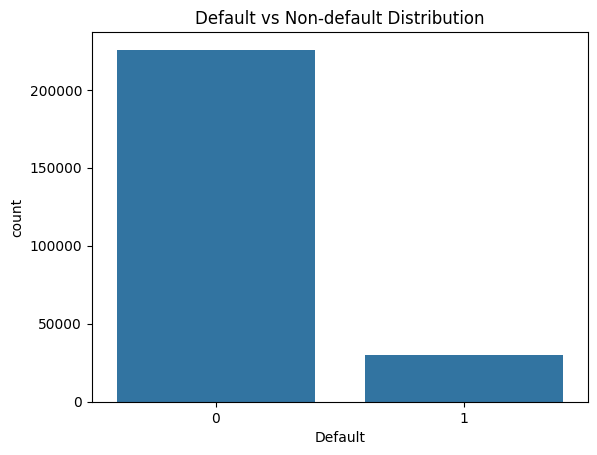

In [18]:
sns.countplot(x="Default", data=df)
plt.title("Default vs Non‑default Distribution")
plt.show()

The dataset is imbalanced. It contains many more non‑defaults than defaults.

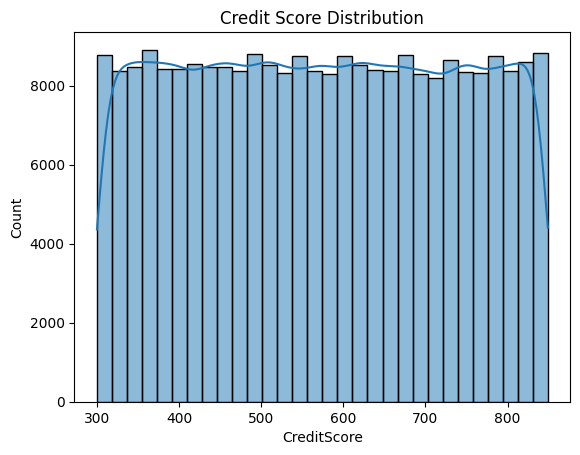

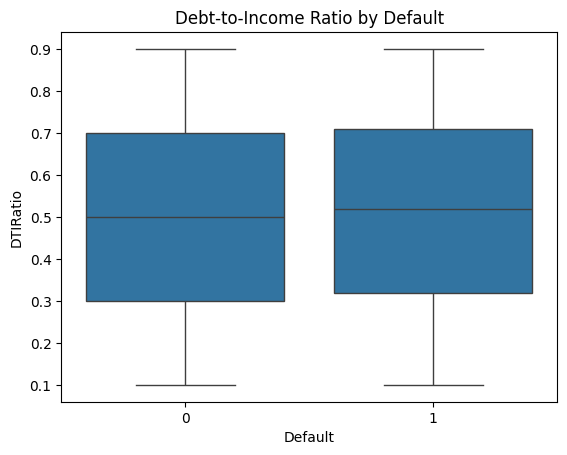

In [19]:
sns.histplot(df["CreditScore"], bins=30, kde=True)
plt.title("Credit Score Distribution")
plt.show()

sns.boxplot(x="Default", y="DTIRatio", data=df)
plt.title("Debt‑to‑Income Ratio by Default")
plt.show()

In [20]:
#Encoding
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(col, df[col].nunique())

LoanID 255347
Education 4
EmploymentType 4
MaritalStatus 3
HasMortgage 2
HasDependents 2
LoanPurpose 5
HasCoSigner 2


In [21]:
# Drop unique ID
df = df.drop('LoanID', axis=1)

# One-hot encode low-cardinality categorical columns
df = pd.get_dummies(df, columns=['Education', 'MaritalStatus'], drop_first=True)

# Label encode small categorical columns
le_cols = ['EmploymentType', 'LoanPurpose']
le = LabelEncoder()
for col in le_cols:
    df[col] = le.fit_transform(df[col])

# Convert binary columns from 'Yes'/'No' to 1/0
binary_cols = ['HasMortgage', 'HasDependents', 'HasCoSigner']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [23]:
X = df.drop('Default', axis=1)
y = df['Default']

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
# Handle Imbalanced Target (SMOTE)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())

Before SMOTE: Default
0    180555
1     23722
Name: count, dtype: int64
After SMOTE: Default
0    180555
1    180555
Name: count, dtype: int64


In [26]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

In [27]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train_scaled, y_train_sm)
y_pred_rf = rf_model.predict(X_test_scaled)

In [29]:
# Random Forest Evaluation
rf_cm = confusion_matrix(y_test, y_pred_rf)
print(rf_cm)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:,1]))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

[[42199  2940]
 [ 4863  1068]]
Random Forest Accuracy: 0.8472097121597807
ROC-AUC: 0.7070388572387741

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.92     45139
           1       0.27      0.18      0.21      5931

    accuracy                           0.85     51070
   macro avg       0.58      0.56      0.57     51070
weighted avg       0.82      0.85      0.83     51070



In [32]:
# RF - Feature Importance
rf_feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

rf_feat_importance.head(10)

,Feature,Importance
0,Age,0.111317
6,InterestRate,0.094277
7,LoanTerm,0.091077
1,Income,0.073952
4,MonthsEmployed,0.070698
2,LoanAmount,0.064791
3,CreditScore,0.057379
13,HasCoSigner,0.056376
8,DTIRatio,0.055972
11,HasDependents,0.053532


# Random Forest

1. Random Forest favors predicting non-defaults due to high class imbalance.

2. It’s accurate overall, but fails to detect most actual defaults, which is critical in banking.

3. Age, interest rate, and loan term are the most influential predictors for default behavior.

In [30]:
# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    random_state=42,
    scale_pos_weight=(y_train.value_counts()[0]/y_train.value_counts()[1])
)

xgb_model.fit(X_train_scaled, y_train_sm)
y_pred_xgb = xgb_model.predict(X_test_scaled)

In [31]:
xgb_cm = confusion_matrix(y_test, y_pred_xgb)
print(xgb_cm)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test_scaled)[:,1]))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

[[23470 21669]
 [ 1211  4720]]
XGBoost Accuracy: 0.5519874681809281
ROC-AUC: 0.7278118543134838

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.52      0.67     45139
           1       0.18      0.80      0.29      5931

    accuracy                           0.55     51070
   macro avg       0.56      0.66      0.48     51070
weighted avg       0.86      0.55      0.63     51070



In [33]:
# Feature Importance - SGBoost
xgb_feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

xgb_feat_importance.head(10)

,Feature,Importance
13,HasCoSigner,0.117022
11,HasDependents,0.103121
17,MaritalStatus_Married,0.098743
10,HasMortgage,0.093238
7,LoanTerm,0.084517
15,Education_Master's,0.073272
18,MaritalStatus_Single,0.071903
16,Education_PhD,0.071096
14,Education_High School,0.069642
0,Age,0.049861


# XGBoost

1. XGBoost greatly improves recall for defaults, which is crucial for banking risk.

2. Tradeoff: lower overall accuracy and many false positives.

3. Important features shift to social and financial commitments (co-signer, dependents, marital status) rather than just loan/age variables.

# Key Insights
1. Random Forest is safer for overall accuracy but misses most high-risk borrowers.

2. XGBoost is better for banking risk management because catching defaults is more important than total accuracy.

3. In real-world credit risk, XGBoost’s high recall is preferable even at the cost of lower accuracy.

In [40]:

# Save as binary
xgb_model.save_model("C:/AMOD/Extensive_bank/models/xgboost_loan_default.bin")

C:\Users\mehta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\xgboost\core.py:158: UserWarning: [22:16:42] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
